# Domain Representation and Literature Bias

This notebook investigates the distribution and potential representation bias of cognitive domains within the Neurosynth database. Because meta-analytic results can be skewed by the sheer volume of studies in a particular field, we aim to quantify how many studies explicitly target our three primary networks of interest: Affect (Emotion), Social cognition, and Valuation (Reward).

We assess the overlap of these studies both at the whole-brain level and strictly within our target VMPFC mask, comparing findings across a restricted (top 15) and a broader (top 50) set of cognitive terms.

In [24]:
from neurosynth import Dataset
from neurosynth.analysis.cluster import Clusterable
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, davies_bouldin_score, silhouette_score
from sklearn.decomposition import PCA
from copy import deepcopy
import joblib
from pathlib import Path
import nibabel as nib
import numpy as np
import nilearn.plotting as nplt
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from scipy.stats import chi2_contingency

plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.grid'] = False

DATA_PATH = Path('../data')
RESULTS_PATH = Path('../results')
PLOTS_PATH = Path('../plots')
DOCUMENTS_PATH = Path('../documents')
PLOT_KWARGS_DICT = dict(dpi=300, transparent=True, bbox_inches='tight')
DOMAIN_MAP_COLOR_DICT = {'affect': '#c00000', 'social': '#0036d9', 'valuation': '#eab200'}
DATASET_FILE = DATA_PATH / 'neurosynth_data/dataset.pkl'
ROI_FILE = DATA_PATH / 'masks/VMPFC_mask_v2.nii'
unROI_FILE = DATA_PATH / 'masks/unVMPFC_mask_v2.nii'
VMPFC_mask = nib.load(RESULTS_PATH / 'nii/K3.nii.gz').get_fdata() > 0

In [25]:
dataset = Dataset.load(DATASET_FILE)

with open(DATA_PATH / 'neurosynth_data/term_mapping.json', 'r', encoding='utf8') as f:
    term_mapping_dict = json.load(f)
    term_list = list(term_mapping_dict.keys())

term_mapping_dict_50 = {k: v for (k, v) in term_mapping_dict.items() if v != "others"}
term_list_50 = list(term_mapping_dict_50.keys())

term_list_15 = term_list_50[:15]
term_mapping_dict_15 = {k: v for k, v in term_mapping_dict.items() if k in term_list_15}

/home/guoqiu/.conda/envs/vmpfc_nsplus/lib/python3.8/site-packages/neurosynth/base/dataset.py:769: FutureWarning: DataFrame.to_sparse is deprecated and will be removed in a future version
  self.data = pd.DataFrame(self.data['values'].todense(),


# Isolating VMPFC Literature

We first identify the baseline subset of the literature relevant to our region of interest. By querying the dataset against our overall VMPFC mask, we extract the unique identifiers for all studies that report at least one activation focus within this specific anatomical boundary.

In [26]:
## VMPFC
VMPFC_id_set = set(dataset.get_studies(mask=VMPFC_mask))

# Study Extraction: Restricted Term Set (Top 15)

To categorize the literature, we map the top 15 highly relevant Neurosynth terms into our three predefined cognitive domains. For each domain, we retrieve the union of study IDs that feature these terms in their abstracts. This extraction is performed twice: once for the entire database (whole-brain) and once restricted to the VMPFC-activating subset.

In [27]:
# domain: [terms]
domain_mapping_dict_15 = {'affect': [], 'social': [], 'valuation': []}
for term, domain in term_mapping_dict_15.items():
    domain_mapping_dict_15[domain].append(term)

# domain map study_id
## Whole brain
domain_map_study_id_dict_15_brain = dict()
for domain, domain_term_list in domain_mapping_dict_15.items():
    domain_id_set = set()
    for term in domain_term_list:
        id_set = set(dataset.get_studies(features=[term.lower()], frequency_threshold=0.001))
        domain_id_set.update(id_set)
    domain_map_study_id_dict_15_brain[domain] = domain_id_set

domain_map_study_id_dict_15_VMPFC = {k: v & VMPFC_id_set for k, v in domain_map_study_id_dict_15_brain.items()}

/home/guoqiu/.conda/envs/vmpfc_nsplus/lib/python3.8/site-packages/neurosynth/base/dataset.py:716: FutureWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ix-indexer-is-deprecated
  feature_weights = self.data.ix[:, features]
/home/guoqiu/.conda/envs/vmpfc_nsplus/lib/python3.8/site-packages/pandas/core/indexing.py:822: FutureWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ix-indexer-is-deprecated
  retval = getattr(retval, self.name)._getitem_axis(key, axis=i)
/home/guoqiu/.conda/envs/vmpfc_nsplus/lib/python3.8/site-packages/pandas/core/frame.py:3471: FutureWarning: SparseSeries is deprecated and will be removed in a future version.
Use a Series with sparse values instead.

    >>> series

# Study Extraction: Extended Term Set (Top 50)

To ensure our representation analysis is not overly sensitive to the specific selection of the top 15 terms, we repeat the exact same study extraction protocol using an expanded dictionary of 50 relevant cognitive terms.

In [28]:
# domain: [terms]
domain_mapping_dict_50 = {'affect': [], 'social': [], 'valuation': []}
for term, domain in term_mapping_dict_50.items():
    domain_mapping_dict_50[domain].append(term)

# domain map study_id
domain_map_study_id_dict_50_brain = dict()
for domain, domain_term_list in domain_mapping_dict_50.items():
    domain_id_set = set()
    for term in domain_term_list:
        id_set = set(dataset.get_studies(features=[term.lower()], frequency_threshold=0.001))
        domain_id_set.update(id_set)
    domain_map_study_id_dict_50_brain[domain] = domain_id_set

domain_map_study_id_dict_50_VMPFC = {k: v & VMPFC_id_set for k, v in domain_map_study_id_dict_50_brain.items()}

# Visualizing Domain Overlap (Venn Diagrams)

Finally, we generate proportional Venn diagrams to visualize the intersections of the literature across the Affect, Social, and Valuation domains.

For both the 15-term and 50-term analyses, we plot two diagrams side-by-side:
* **Left:** The distribution of studies across the entire Neurosynth database.
* **Right:** The distribution of studies specifically reporting activations within the VMPFC.

This visualization helps clarify whether the functional overlap observed in the VMPFC is a true regional property or merely a reflection of general co-occurrence trends in the broader neuroimaging literature.

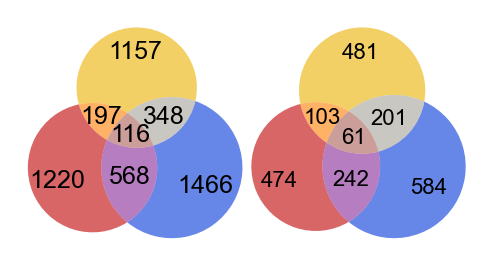

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))

ax = axes[0]

v = venn3(
    subsets=[domain_map_study_id_dict_15_brain[k] for k in DOMAIN_MAP_COLOR_DICT.keys()],
    set_labels=[''] * 3,
    set_colors=DOMAIN_MAP_COLOR_DICT.values(),
    alpha=0.6,
    ax=ax
)

for text in v.subset_labels:
    if text is not None:
        text.set_fontsize(18)
ax.invert_yaxis()

ax = axes[1]
v = venn3(
    subsets=[domain_map_study_id_dict_15_VMPFC[k] for k in DOMAIN_MAP_COLOR_DICT.keys()],
    set_labels=[''] * 3,
    set_colors=DOMAIN_MAP_COLOR_DICT.values(),
    alpha=0.6,
    ax=ax
)

for text in v.subset_labels:
    if text is not None:
        text.set_fontsize(16)
ax.invert_yaxis()
plt.subplots_adjust(wspace=-0.3, hspace=0)
fig.savefig(PLOTS_PATH / 'bias/neurosynth_domain_StudyNumber15.png', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH / 'bias/neurosynth_domain_StudyNumber15.svg', **PLOT_KWARGS_DICT)

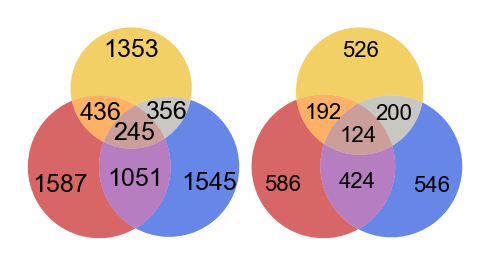

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))

ax = axes[0]

v = venn3(
    subsets=[domain_map_study_id_dict_50_brain[k] for k in DOMAIN_MAP_COLOR_DICT.keys()],
    set_labels=[''] * 3,
    set_colors=DOMAIN_MAP_COLOR_DICT.values(),
    alpha=0.6,
    ax=ax
)

for text in v.subset_labels:
    if text is not None:
        text.set_fontsize(18)
ax.invert_yaxis()

ax = axes[1]
v = venn3(
    subsets=[domain_map_study_id_dict_50_VMPFC[k] for k in DOMAIN_MAP_COLOR_DICT.keys()],
    set_labels=[''] * 3,
    set_colors=DOMAIN_MAP_COLOR_DICT.values(),
    alpha=0.6,
    ax=ax
)

for text in v.subset_labels:
    if text is not None:
        text.set_fontsize(16)
ax.invert_yaxis()
plt.subplots_adjust(wspace=-0.3, hspace=0)

fig.savefig(PLOTS_PATH / 'bias/neurosynth_domain_StudyNumber50.png', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH / 'bias/neurosynth_domain_StudyNumber50.svg', **PLOT_KWARGS_DICT)